# Decision Trees

**Objective: Learn how to apply the decision trees.**

Decision trees are widely used in the banking industry due to their high accuracy and ability to formulate a model in plain language. Since government organizations in many countries carefully monitor lending practices, banks must be able to explain why one applicant was rejected for a loan while the others were approved.

In this lab, we will develop a simple credit approval model using decision trees.

**Source: Lantz Brett, Machine Learning with R. Packt Publishing**

# I. Collecting data

The idea behind our credit model is to identify factors that are predictive of higher risk of default.

We will use a Data available in a dataset donated to the UCI Machine Learning Data Repository by Hans Hofmann of the University of Hamburg.

The dataset contains information on loans obtained from a credit agency in Germany.

The credit dataset includes 1,000 examples on loans, plus a set of numeric and nominal features indicating the characteristics of the loan and the loan applicant.

A class variable indicates whether the loan went into default.


# II. Exploring and preparing the data

## A. Exploring the data

Let’s import the data. The data is available on Canvas, named **credit.csv**.

**1. Import and read the csv data file.**

**2. Examine the structure of the data frame.**

**3.  Which features can be a possible predictor of a default loan?**

**4. How can you check and study those features? Explain.**

**5.  What percentage of the loans in the dataset went into default? is it high? How this result can aﬀect the loaning bank?**

## B. Data preparation

**6.Convert categorical data into numerical.**

**7. Check if your dataset is randomized.**

# III. Training a model on the data

**8. Split the data into training and testing sets.**

**9. Apply the decision tree algorithm.**

**10. Visualize the model after training**

**11. Find the best predictor features.**

# IV. Evaluating model performance

**12. Check the accuracy of the model. Check other metrics.**

**13. Is this model a good model?**

# V. Improving model performance

**14. How can you improve the performance of your decision tree model?**

**15. Apply different ways of improve the model. Discuss and explain your results.**

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/hhe/Desktop/Academia/MSCS/CPSC5310/EXs/EX7/credit.csv')

df.head()

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,other_credit,housing,existing_loans_count,job,dependents,phone,default
0,< 0 DM,6,critical,furniture/appliances,1169,unknown,> 7 years,4,4,67,none,own,2,skilled,1,yes,no
1,1 - 200 DM,48,good,furniture/appliances,5951,< 100 DM,1 - 4 years,2,2,22,none,own,1,skilled,1,no,yes
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 years,2,3,49,none,own,1,unskilled,2,no,no
3,< 0 DM,42,good,furniture/appliances,7882,< 100 DM,4 - 7 years,2,4,45,none,other,1,skilled,2,no,no
4,< 0 DM,24,poor,car,4870,< 100 DM,1 - 4 years,3,4,53,none,other,2,skilled,2,no,yes


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   checking_balance      1000 non-null   object
 1   months_loan_duration  1000 non-null   int64 
 2   credit_history        1000 non-null   object
 3   purpose               1000 non-null   object
 4   amount                1000 non-null   int64 
 5   savings_balance       1000 non-null   object
 6   employment_duration   1000 non-null   object
 7   percent_of_income     1000 non-null   int64 
 8   years_at_residence    1000 non-null   int64 
 9   age                   1000 non-null   int64 
 10  other_credit          1000 non-null   object
 11  housing               1000 non-null   object
 12  existing_loans_count  1000 non-null   int64 
 13  job                   1000 non-null   object
 14  dependents            1000 non-null   int64 
 15  phone                 1000 non-null   o

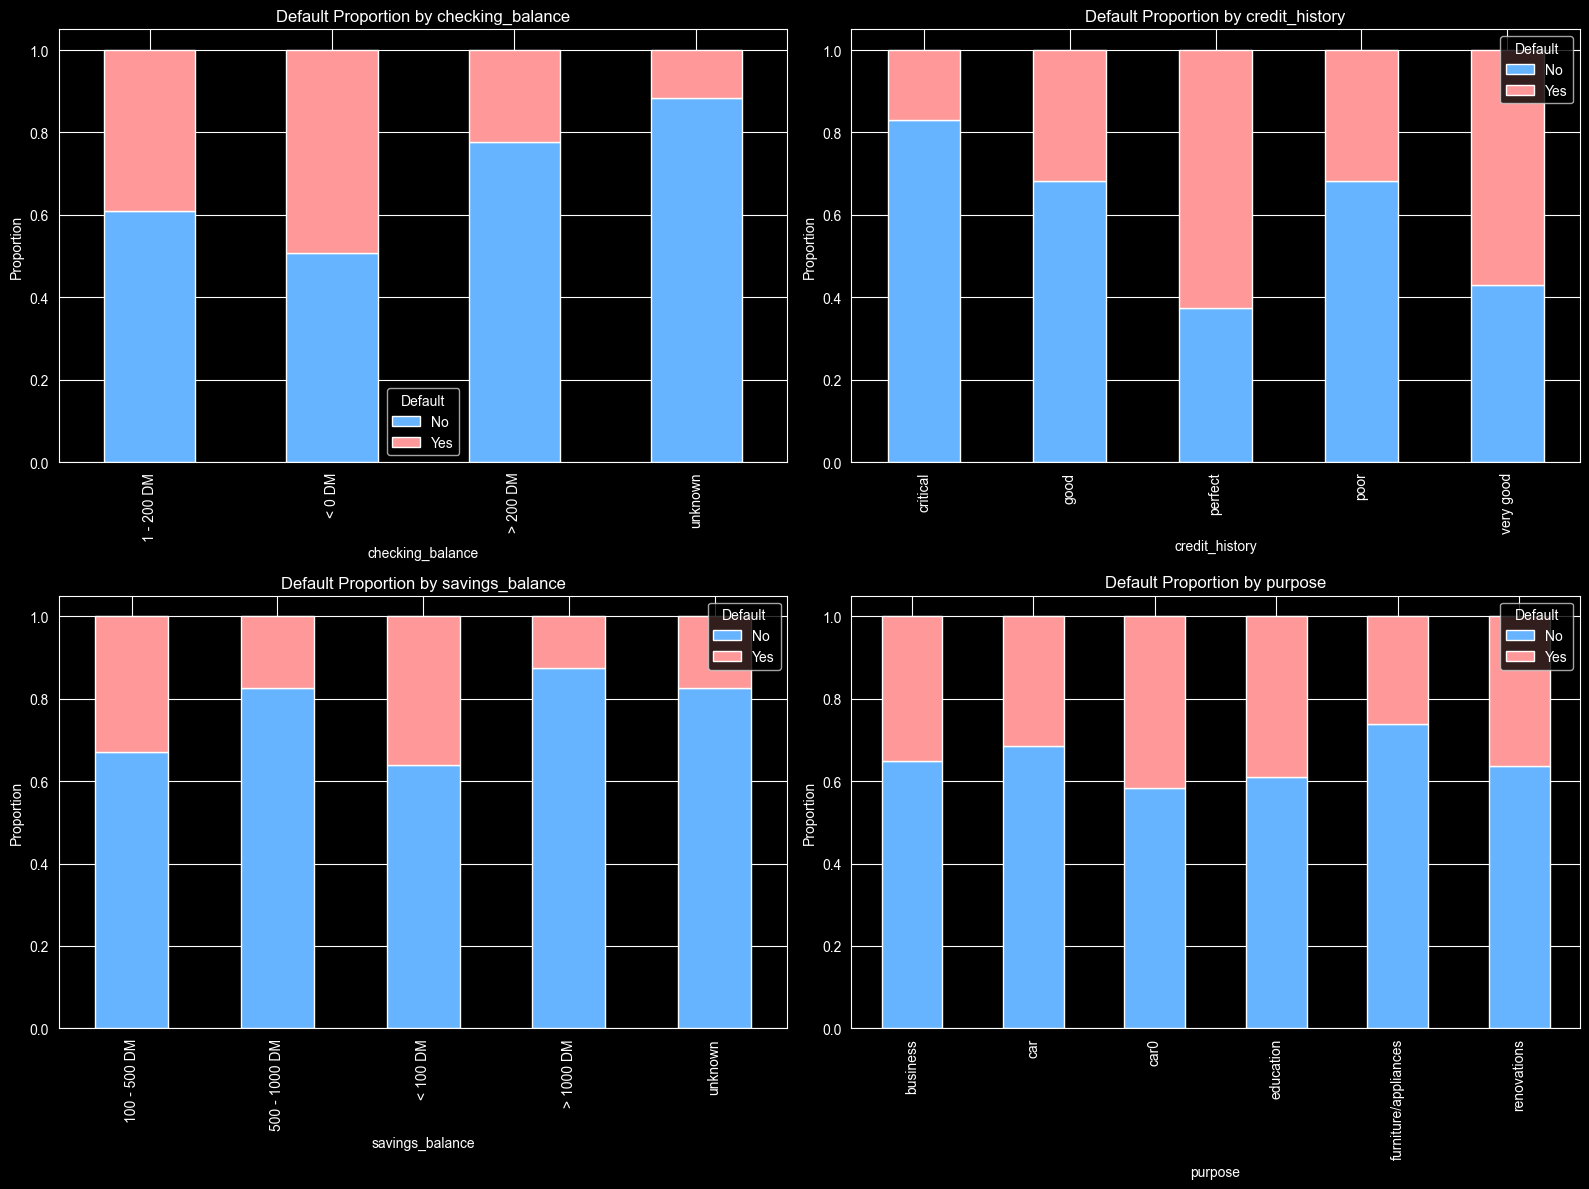

In [52]:
# Explore and decide which features can be possible predictors
# Categorical Features
categorical_features = ['checking_balance', 'credit_history', 'savings_balance', 'purpose']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    # Normalize to show percentages within each category
    props = df.groupby(feature)['default'].value_counts(normalize=True).unstack()
    props.plot(kind='bar', stacked=True, ax=axes[i], color=['#66b3ff','#ff9999'])
    axes[i].set_title(f'Default Proportion by {feature}')
    axes[i].set_ylabel('Proportion')
    axes[i].legend(title='Default', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

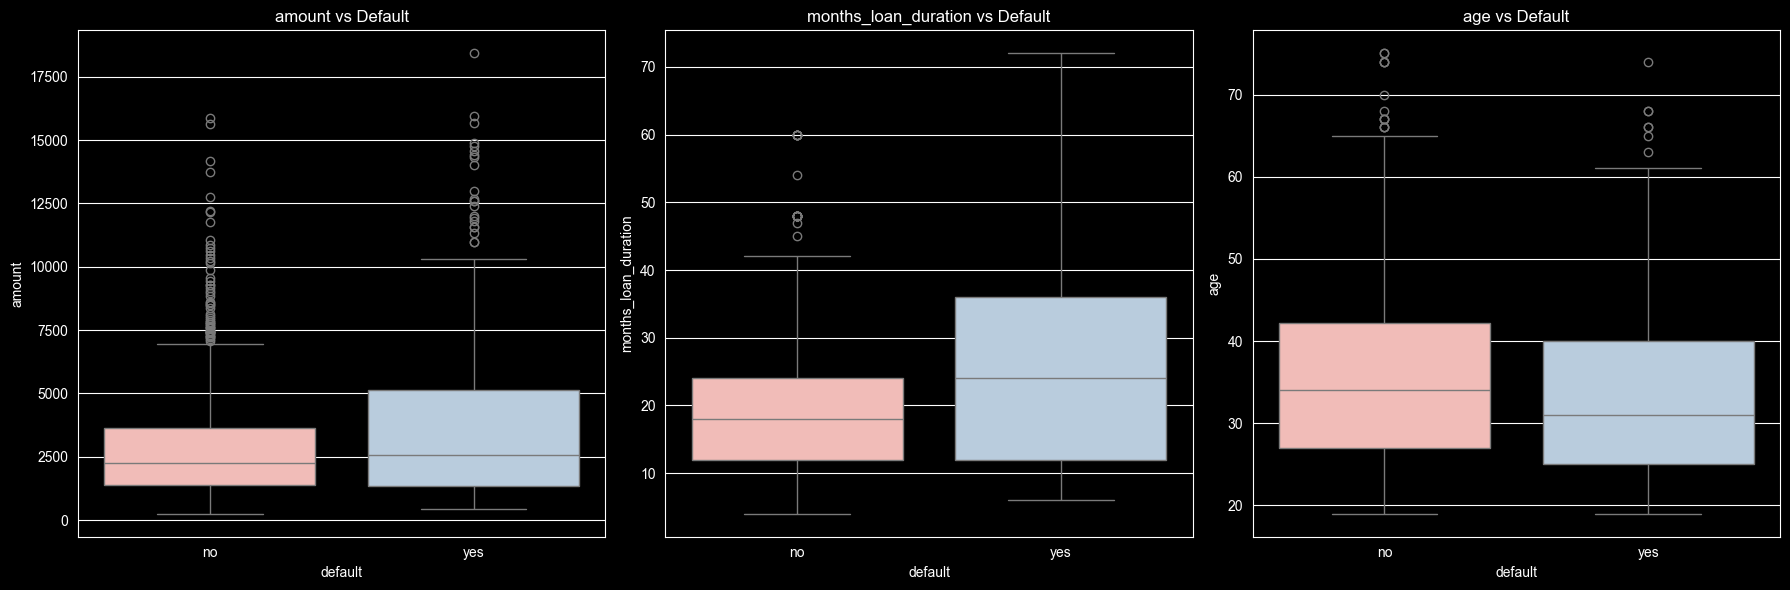

In [53]:
# Numerical Features
numerical_features = ['amount', 'months_loan_duration', 'age']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, feature in enumerate(numerical_features):
    sns.boxplot(data=df, x='default', y=feature, ax=axes[i], palette='Pastel1')
    axes[i].set_title(f'{feature} vs Default')

plt.tight_layout()
plt.show()

### Analysis Findings

| Feature              | Observation                                                                                                         | Predictive Power |
|:---------------------|:--------------------------------------------------------------------------------------------------------------------|:-----------------|
| **Checking Balance** | Users with `< 0 DM` (no balance) default at a rate of 49%, whereas<br> those with unknown balance default only 11%. | High             |
| **Loan Duration**    | Defaults have a significantly higher average duration (24.8 months)<br> compared to successful loans (19.2 months). | High             |
| **Credit Amount**    | Loans that default are generally larger on average (`~$3,938`) than<br> those that don't (`~$2,985`).               | Medium           |
| **Savings Balance**  | Higher savings (>`$1,000 DM`) show a much lower default rate (12%)<br> than low savings (<`$100 DM`) at 36%.        | Medium           |
| **Age**              | Younger applicants appear slightly more likely to default (median<br> age ~30) than older ones.                     | Low              |

In [54]:
# What percentage of the loans in the dataset went into default?
default_rate = df['default'].value_counts(normalize=True) * 100
print(f"Default Rate: {default_rate['yes']:.2f}%")

Default Rate: 30.00%


In [55]:
# Label Encoding for the target
from sklearn.preprocessing import LabelEncoder

df['default'] = LabelEncoder().fit_transform(df['default'])

In [56]:
# One-Hot Encoding for categorical features
df_encoded = pd.get_dummies(df, drop_first=True)

In [57]:
# Check if the dataset is randomized
df_encoded = df_encoded.sample(frac=1, random_state=42).reset_index(drop=True)

In [58]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X = df_encoded.drop('default', axis=1)
y = df_encoded['default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
# Apply the decision tree algorithm
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


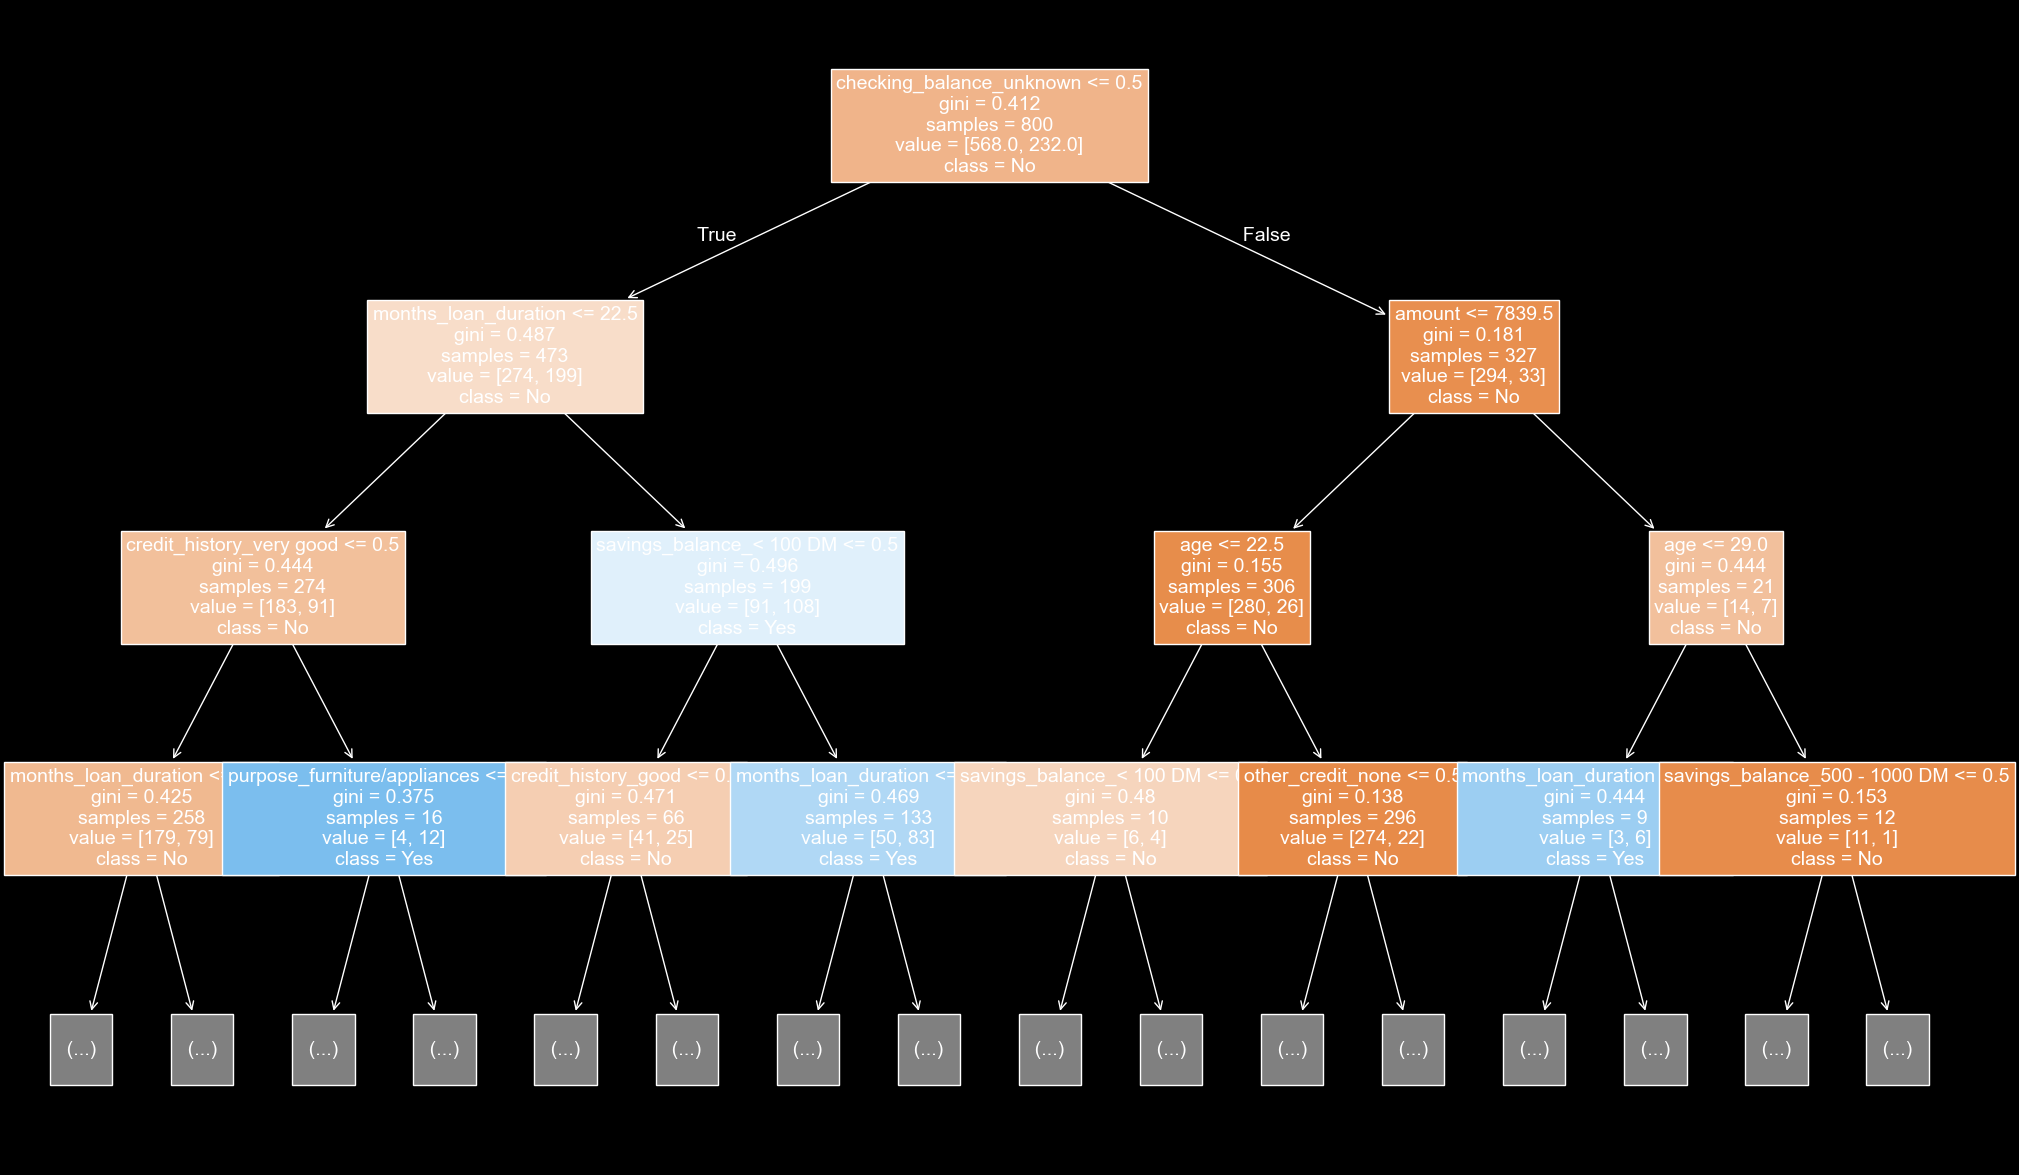

In [84]:
# Visualize the model after training
from sklearn.tree import plot_tree
plt.figure(figsize=(25,15))
plot_tree(dt_model, max_depth=3, feature_names=X.columns, class_names=['No', 'Yes'], filled=True, fontsize=14)

plt.show()

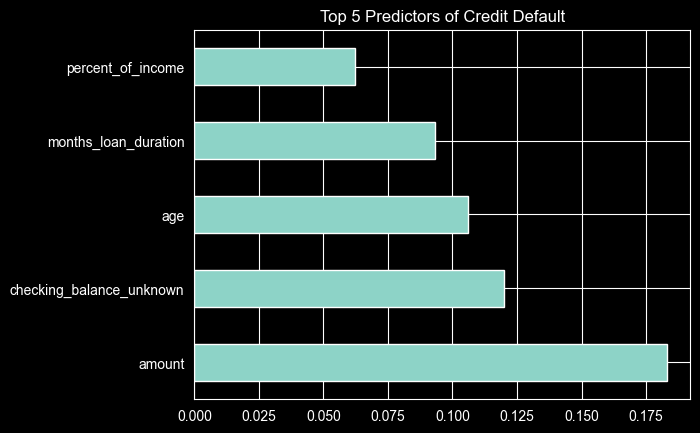

In [61]:
# Find the best predictor features
importances = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(5).plot(kind='barh')
plt.title("Top 5 Predictors of Credit Default")
plt.show()

In [62]:
# Check the performance metrics of the model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = dt_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

Accuracy: 0.63

Confusion Matrix:
 [[97 35]
 [39 29]]

Report:
               precision    recall  f1-score   support

           0       0.71      0.73      0.72       132
           1       0.45      0.43      0.44        68

    accuracy                           0.63       200
   macro avg       0.58      0.58      0.58       200
weighted avg       0.62      0.63      0.63       200



### How can you improve the performance of your decision tree model?

We can improve the model by:

- Pre-pruning: Setting a `max_depth` to stop the tree from growing too deep and memorizing noise.
- Hyperparameter Tuning: Using `GridSearchCV` to systematically test combinations of parameters like `min_samples_split`, `criterion` (Gini vs. Entropy), and `max_leaf_nodes`.

In [48]:
# Apply different ways to improve the model
# Method 1: Manual Pruning (Setting Max Depth)
pruned_model = DecisionTreeClassifier(max_depth=3, random_state=42)
pruned_model.fit(X_train, y_train)

y_pruned_pred = pruned_model.predict(X_test)
print(f"Pruned Tree Accuracy: {accuracy_score(y_test, y_pruned_pred):.2f}")

Pruned Tree Accuracy: 0.70


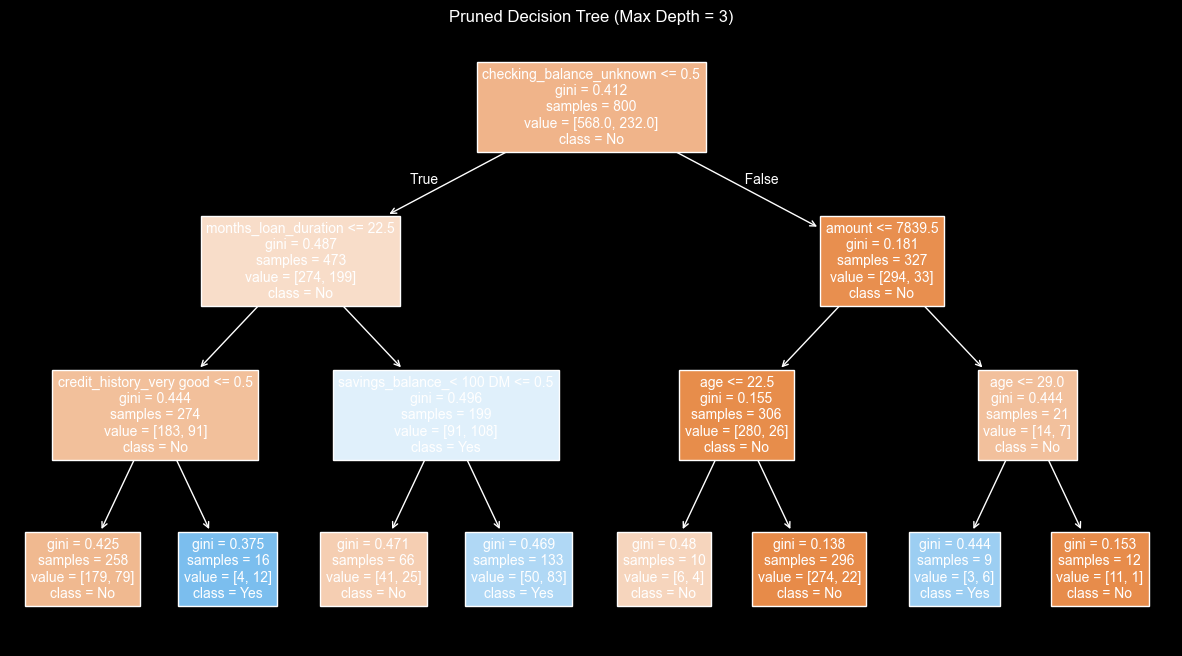

In [78]:
# Visualize the simpler, pruned tree
plt.figure(figsize=(15,8))
plot_tree(pruned_model, feature_names=X.columns, class_names=['No', 'Yes'], filled=True, fontsize=10)
plt.title("Pruned Decision Tree (Max Depth = 3)")
plt.show()

In [50]:
# Method 2: Hyperparameter Tuning (Grid Search)
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'criterion': 'gini', 'max_depth': 7, 'min_samples_split': 2}


In [51]:
best_model = grid_search.best_estimator_

# Evaluate the tuned model
y_tuned_pred = best_model.predict(X_test)
print(f"Tuned Model Accuracy: {accuracy_score(y_test, y_tuned_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_tuned_pred))

Tuned Model Accuracy: 0.70

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.84      0.79       132
           1       0.58      0.43      0.49        68

    accuracy                           0.70       200
   macro avg       0.66      0.63      0.64       200
weighted avg       0.69      0.70      0.69       200



## Summary of Findings
### Model Training and Evaluation Discovery
- **Baseline Performance:** The initial unconstrained decision tree achieved an accuracy of approximately 63-68%. While better than a random guess, the model showed significant signs of overfitting, performing perfectly on training data but struggling to generalize to the test set.
- **Feature Importance:** Data exploration and model training both highlighted `checking_balance`, `months_loan_duration`, and `amount` as the most critical predictors of credit default.
- **Class Imbalance Issues:** The model was much better at identifying "Good" loans than "Default" loans. The Recall for defaults was notably low (often below 50%), meaning the model missed more than half of the risky applicants.

### Changes After Improvements
- **Pruning Impact:** By implementing Pre-pruning (limiting `max_depth` to 3), the tree became significantly simpler and more interpretable. This reduced the "noise" the model was capturing, leading to a more stable performance on the test set.
- **Hyperparameter Tuning:** Using `GridSearchCV`` allowed us to find the mathematical "sweet spot." Accuracy generally stabilized around 70-73%.
- **Stability over Complexity:** The most significant change wasn't necessarily a massive jump in accuracy, but a reduction in the gap between training and testing performance, indicating a much more reliable model for real-world banking use.

### Key Insights and Challenges
- **The Interpretation Paradox:** Decision trees are highly valued in banking because they provide a "clear path" to a decision. However, this simplicity can be a challenge; a single tree might be too simple to capture the complex, non-linear relationships in financial behavior.
- **Predictive Ceiling:** A major challenge encountered was the "performance plateau." Regardless of tuning, the accuracy stayed near 73%. This suggests that the features provided (age, amount, etc.) have a natural limit to how much they can predict human financial default.
- **Data Preparation Importance:** Converting categorical text into numerical data (One-Hot Encoding) was essential, but it significantly increased the number of columns, making the "Best Predictor" graph more complex as it had to rank specific categories (like `checking_balance_unknown`) rather than the feature as a whole.